# Nasa - Exoplanetas
## Estudo dos mundos já descobertos

 Trabalho Prático de Programação e Algoritmia,
 André Borges 112602,
 André Faria 113318,
 Sara Cardoso 112934
       -  Licenciatura em Física


In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Leitura do ficheiro de excel

In [113]:
df = pd.read_excel('data_exoplanets.xls')
df.head()

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


#### Classe criada para os Exoplanetas

In [114]:
class Exoplanet:
    def __init__(self, df):
        self.df = df
    
    def acceleration(self):

        G = 6.67*10**(-11) # Universal Gravitacional Constant
        
        mass_jupi = 1.90*10**27 # massa de Júpiter em kg
        mass_earth = 5.97*10**24 # massa da Terra em kg

        rad_jupi = 6.9*10**7
        rad_earth = 6.4*10**6

        masses = []
        radii = []
        accelerations = []

        accelerations = []

        for row in df.itertuples():
            if row.mass_wrt == "Jupiter":
                mass = row.mass_multiplier * mass_jupi
            else:
                mass = row.mass_multiplier * mass_earth
            
            if row.radius_wrt == "Jupiter":
                radius = row.radius_multiplier * rad_jupi
            else:
                radius = row.radius_multiplier * rad_earth
            
            m = mass
            masses.append(m)

            r = radius
            radii.append(r)
            
            a = (G*mass)/((radius)**2)
            accelerations.append(a)
        
        self.df["mass_SI"] = masses # Adds a column with exoplanet mass in meters
        self.df["radius_SI"] = radii # Adds a column with exoplanet radius in meters
        self.df["acceleration"] = accelerations # Adds a collumn with gravtitational acceleration 
    
    def get_mass(self):
        if "mass_SI" not in self.df.columns:
            self.acceleration()
        return self.df["mass_SI"]
    
    def get_radius(self):
        if "radius_SI" not in self.df.columns:
            self.acceleration()
        return self.df["radius_SI"]
    
    def discovery_year(self):
        discovery_counts = self.df.groupby(["discovery_year", "detection_method"]).size().reset_index(name = "count")
        method_counts = self.df.groupby(["discovery_year", "detection_method"]).size().reset_index(name = "count")

        max_discovery_year = discovery_counts.groupby("discovery_year")["count"].sum().idxmax()
        max_year_method_counts = method_counts[method_counts["discovery_year"] == max_discovery_year]

        return discovery_counts, max_year_method_counts

    def dist_to_star(self):
        UA=1.496e+11
        distance = self.df["orbital_radius"]*UA
        mean_dist = distance.mean()
        self.df["orbital_radius_meters"]=distance
        return distance, mean_dist
    
    def habitability(self):
        habitability_status = []

        for row in self.df.itertuples():
            if row.planet_type in ["Terrestrial", "Super Earth"]:
                distance = row.orbital_radius
                if 0.53 <= distance <= 1.2:
                    habitability_status.append("Habitable")
                else:
                    habitability_status.append("Not Habitable")
            else:
                habitability_status.append("Not Habitable") 

        self.df["habitability"] = habitability_status  
        # Adds habitability column to the dataframe stored in this program (not the original)             

    def planet_type(self):
        type_counts = self.df["planet_type"].value_counts()
        return type_counts
    
    def planet_viability(self):
        self.habitability()

        habitable_planets = self.df[self.df["habitability"] == "Habitable"]
        closest_habitable_planets = habitable_planets.nsmallest(5, "distance")
        return closest_habitable_planets

### 1. Qual o tipo de exoplanetas que mais existe, e qual é a sua categoria?



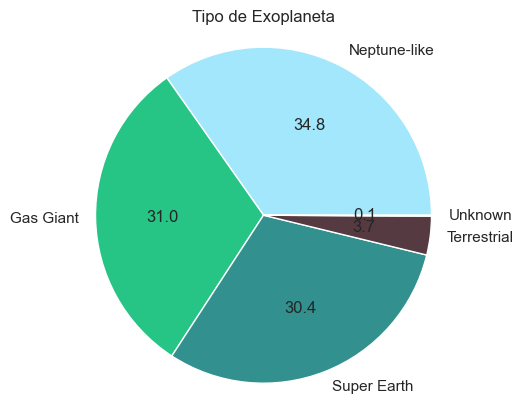

In [115]:
def type():
    exoplanet = Exoplanet(df)
    count_type = exoplanet.planet_type()

    personalized_colours = ['#A3E7FC', '#26C485', '#32908F', '#553A41', '#2F0601']

    plt.pie(count_type, labels=count_type.index, autopct='%1.1f', colors = personalized_colours)
    plt.title('Tipo de Exoplaneta')
    plt.axis('equal')

type()

### 2. Qual é a distância do exoplaneta à sua respetiva estrela? 


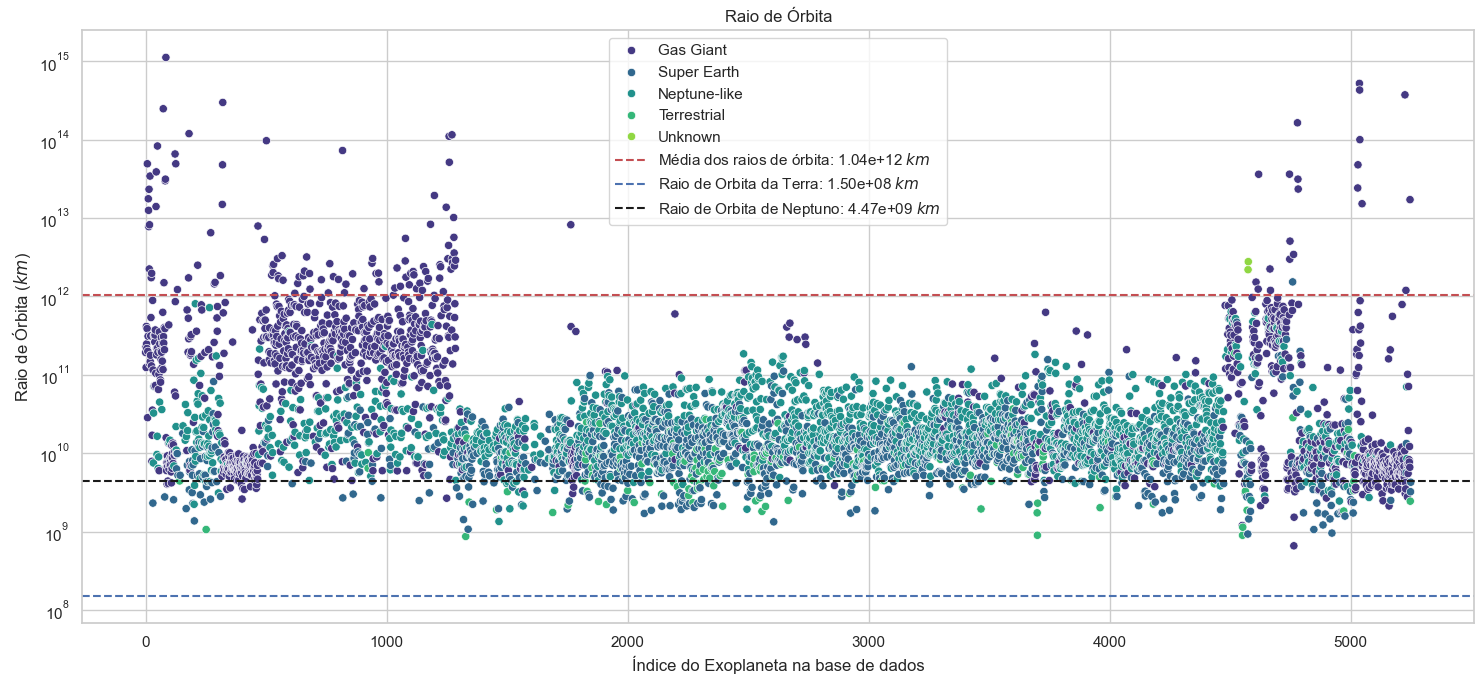

In [116]:
def dist():
    # 1 AU = 1.50*10**8 km (Distância Média entre o Sol e a Terra em metros)

    exoplanet = Exoplanet(df)
    orbi_rad, mean_orbi_rad = exoplanet.dist_to_star()
    orbi_rad_earth = 1.50*10**8
    orbi_rad_neptune = 4.47*10**9

    plt.figure(figsize = (15, 7))
    sns.set_theme(style = "whitegrid")

    ax = sns.scatterplot(x = range(len(orbi_rad)), y = orbi_rad.values, hue = df["planet_type"], palette = "viridis")
    ax.set_title("Raio de Órbita")
    ax.set_xlabel("Índice do Exoplaneta na base de dados")
    ax.set_ylabel("Raio de Órbita ($km$)")
    ax.set_yscale('log') # A escala normal não era conclusiva

    # plot horizontal line representing mean orbital radius
    ax.axhline(mean_orbi_rad, color = 'r', linestyle = "--", label = f"Média dos raios de órbita: {mean_orbi_rad:.2e} $km$")
    ax.axhline(orbi_rad_earth, color = "b", linestyle = "--", label = f"Raio de Orbita da Terra: {orbi_rad_earth:.2e} $km$")
    ax.axhline(orbi_rad_neptune, color = "k", linestyle = "--", label = f"Raio de Orbita de Neptuno: {orbi_rad_neptune:.2e} $km$")
    ax.legend()

    plt.tight_layout()
    plt.show()

dist()

Este gráfico mostra-nos os respetivos raios de órbita, em kilometros, em função do índice na base de dados. Nas duas alíneas seguintes já faremos uma análise mais interessante.  Cada ponto no gráfico corresponde ao raio respetivo de cada exoplaneta.

##### 2.1. Raios de Órbita, mas em função da massa do planeta

Vamos repetir a alínea anterior (2), mas os raios de órbita estão em função da massa de cada planeta em kg.

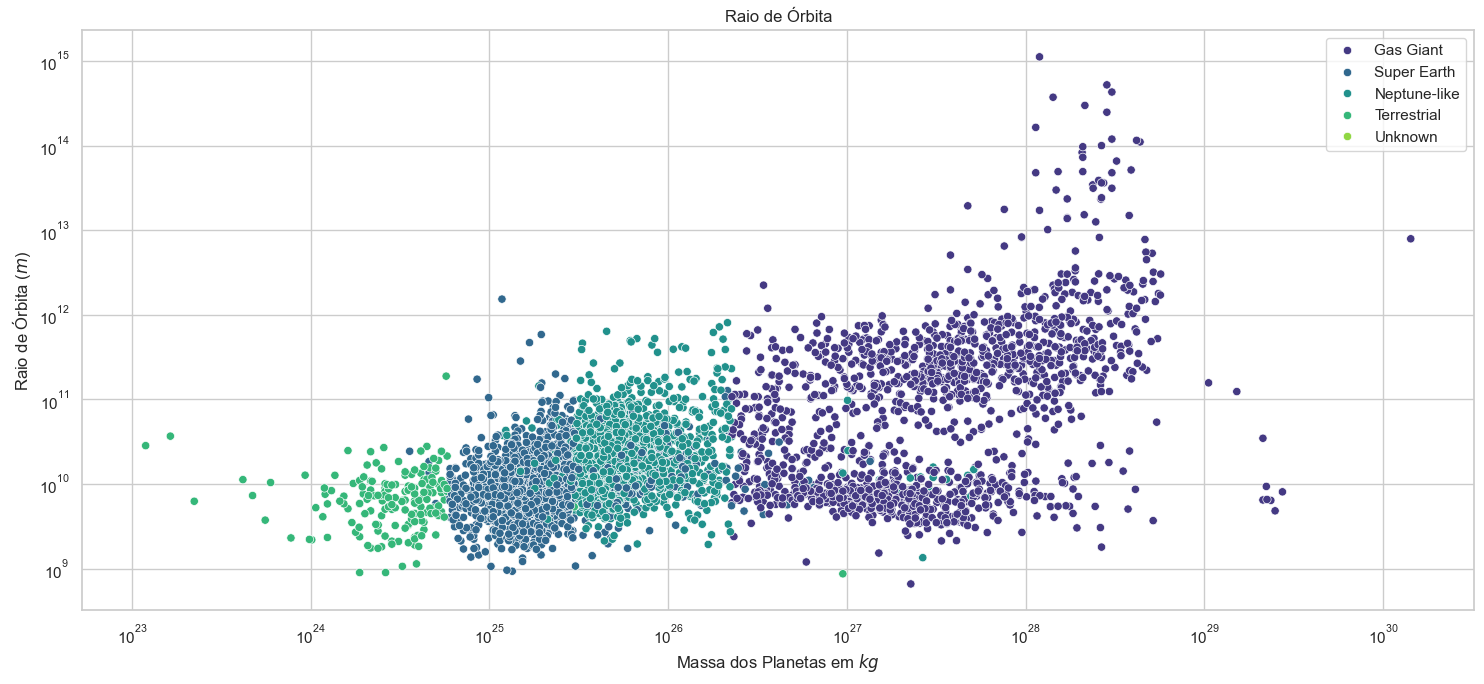

In [117]:
def dist(df):
    exoplanet = Exoplanet(df)
    distance = exoplanet.dist_to_star()[0].values
    mass_SI = exoplanet.get_mass().values

    plt.figure(figsize=(15, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.scatterplot(x=mass_SI, y=distance, hue=df["planet_type"], palette="viridis")
    ax.set_title("Raio de Órbita")
    ax.set_xlabel("Massa dos Planetas em $kg$")
    ax.set_xscale("log")
    ax.set_ylabel("Raio de Órbita ($m$)")
    ax.set_yscale('log')

    ax.legend()
    plt.tight_layout()
    plt.show()

dist(df)


Podemos notar que, apesar de não ser em todos os casos, os exoplanetas estão agrupados por tipo, sendo os "Unknown" e os "Terrestrial" que têm menores raios de órbita para menores massas, enquanto são os "Gas Giants" que têm maiores raios de órbita para maiores massas.

##### 2.2. Raios de órbita, mas em função ao raio do planeta

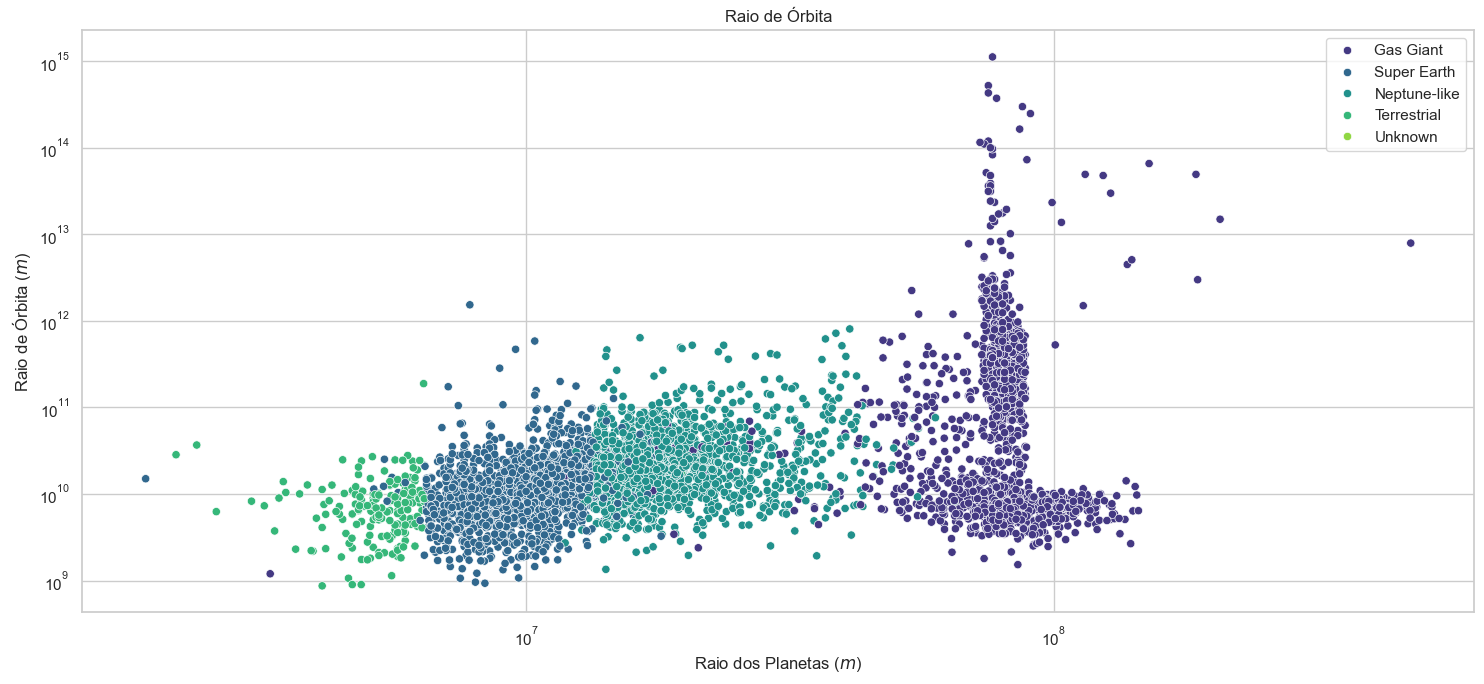

In [118]:
def dist(df):
    exoplanet = Exoplanet(df)
    distance = exoplanet.dist_to_star()[0].values
    radius_SI = exoplanet.get_radius().values

    plt.figure(figsize=(15, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.scatterplot(x=radius_SI, y=distance, hue=df["planet_type"], palette="viridis")
    ax.set_title("Raio de Órbita")
    ax.set_xlabel("Raio dos Planetas ($m$)")
    ax.set_xscale('log')
    ax.set_ylabel("Raio de Órbita ($m$)")
    ax.set_yscale('log')
    
    ax.legend()
    plt.tight_layout()
    plt.show()

dist(df)

Podemos notar que, apesar de não ser em todos os casos, os exoplanetas estão agrupados por tipo, sendo os "Unknown", os "Terrestrial" e os "Super Earth" que têm menores raios de órbita para menores massas, enquanto são os "Gas Giants" que têm maiores raios de órbita para maiores massas.

### 3. Os planetas escolhidos estão na zona habitável?
A zona habitável corresponde à gama de distâncias à sua respetiva estrela, em que o planeta consegue suportar água no seu estado líquido por longos períodos de tempo. 
As dimensões da zona habitável dependem da luminosidade da sua estrela, um parâmetro da estrela diretamente relacionado com a sua temperatura à superfície, ou o seu tipo espectral. Estrelas mais quentes terão zonas habitáveis mais afastadas da estrela e mais extensas. Por oposição, estrelas mais frias terão zonas habitáveis mais próximas da estrela, mas de menor área. 
Em compensação, as estrelas mais frias vivem muito mais tempo do que as estrelas mais quentes, pelo que a vida terá muito mais oportunidades de se desenvolver.

Para determinar se um exoplaneta está na zona habitável é necessário termos informação sobre a estrela, sobre a superfície do planeta, se é rochoso, sobre se a distância até à sua estrela é viável para manter água no estado líquido. 
Como não temos informação sobre a estrela à qual cada planeta orbita, temos de recorrer a outros métodos. Em média, procura-se planetas que esteja entre $0,53 UA < Raio \: de \: órbita <1,1 UA $, onde UA é a Unidade Astronómica, que equivale à distância média entre a Terra e o Sol. O outro fator que estamos à procura é se o exoplaneta é rochoso e se tem uma aceleração gravítica parecida à nossa.

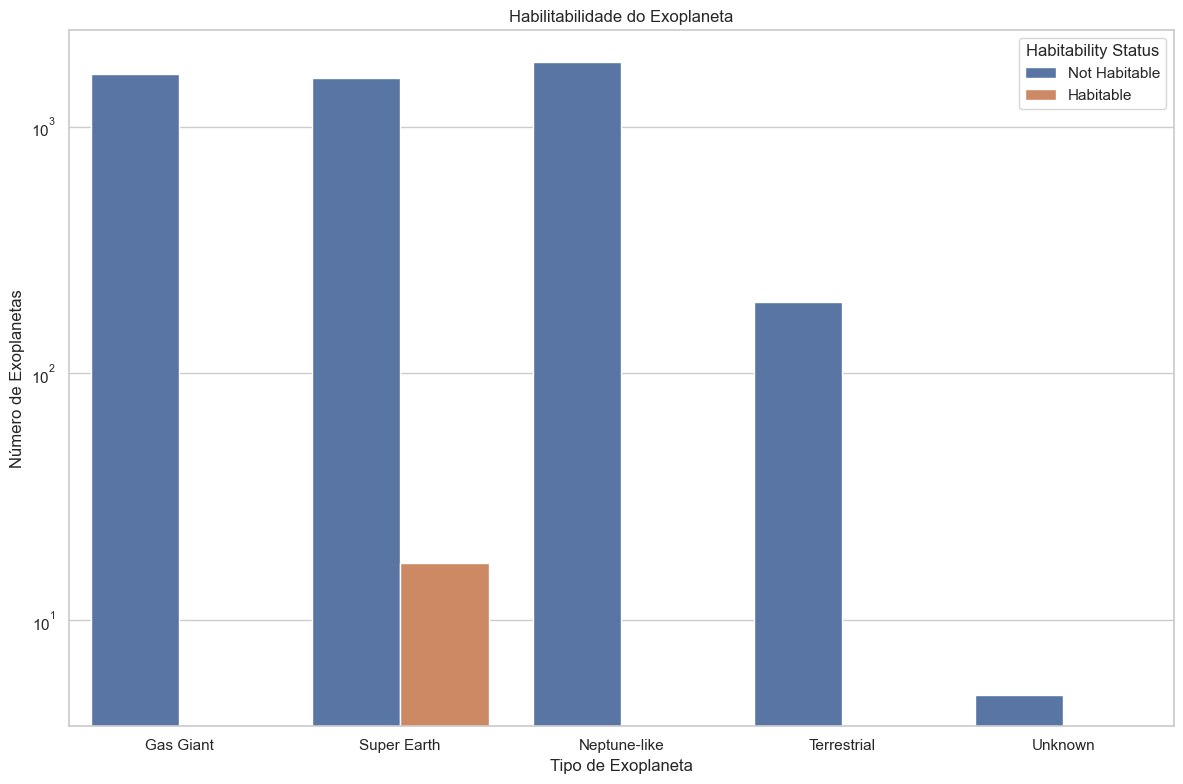

In [119]:
def habi():
    exoplanet = Exoplanet(df)
    exoplanet.habitability()

    plt.figure(figsize = (12, 8))
    sns.countplot(data = df, x = "planet_type", hue = "habitability")
    plt.title("Habilitabilidade do Exoplaneta")
    plt.xlabel("Tipo de Exoplaneta")
    plt.ylabel("Número de Exoplanetas")
    plt.yscale('log')
    plt.legend(title = "Habitability Status")
    plt.tight_layout()
    plt.show()
    
habi()

Aqui, vamos assumir que todos os exoplanetas que sejam do tipo 'Super Earth', são rochosos para conseguirmos continuar esta análise de planetas em que a vida seja viável. Na realidade, as 'Super Earths' são planetas que são mais mássivos que a Terra, mas com uma menor massa do que Neptuno ou Urano, e podem ser rochosos, gasosos, ou uma mistura de ambos. Apesar de os Terrestres serem rochosos, eles estão todos demasiado perto da sua estrela para suportarem água líquida.

### 4. Massa do Exoplaneta e a sua aceleração gravítica
Usamos a Fórmula da Gravitação Universal de Newton, que nos diz que a força de atração $F=\frac{G \times M \times m}{R^2}$  entre duas massas é diretamente proporcional a cada uma das massas sobre a distância entre elas ao quadrado. Neste caso, usando a fórmula da 2ª Lei de Newton, $F = m \times a$, como estamos a calcular a aceleração gravítica de cada exoplaneta $a$, usamos a Massa do planeta, $M$, sobre o seu raio ao quadrado, $R^2$.

Ou seja, 
$
a=\frac{G \times M}{R^2}.
$

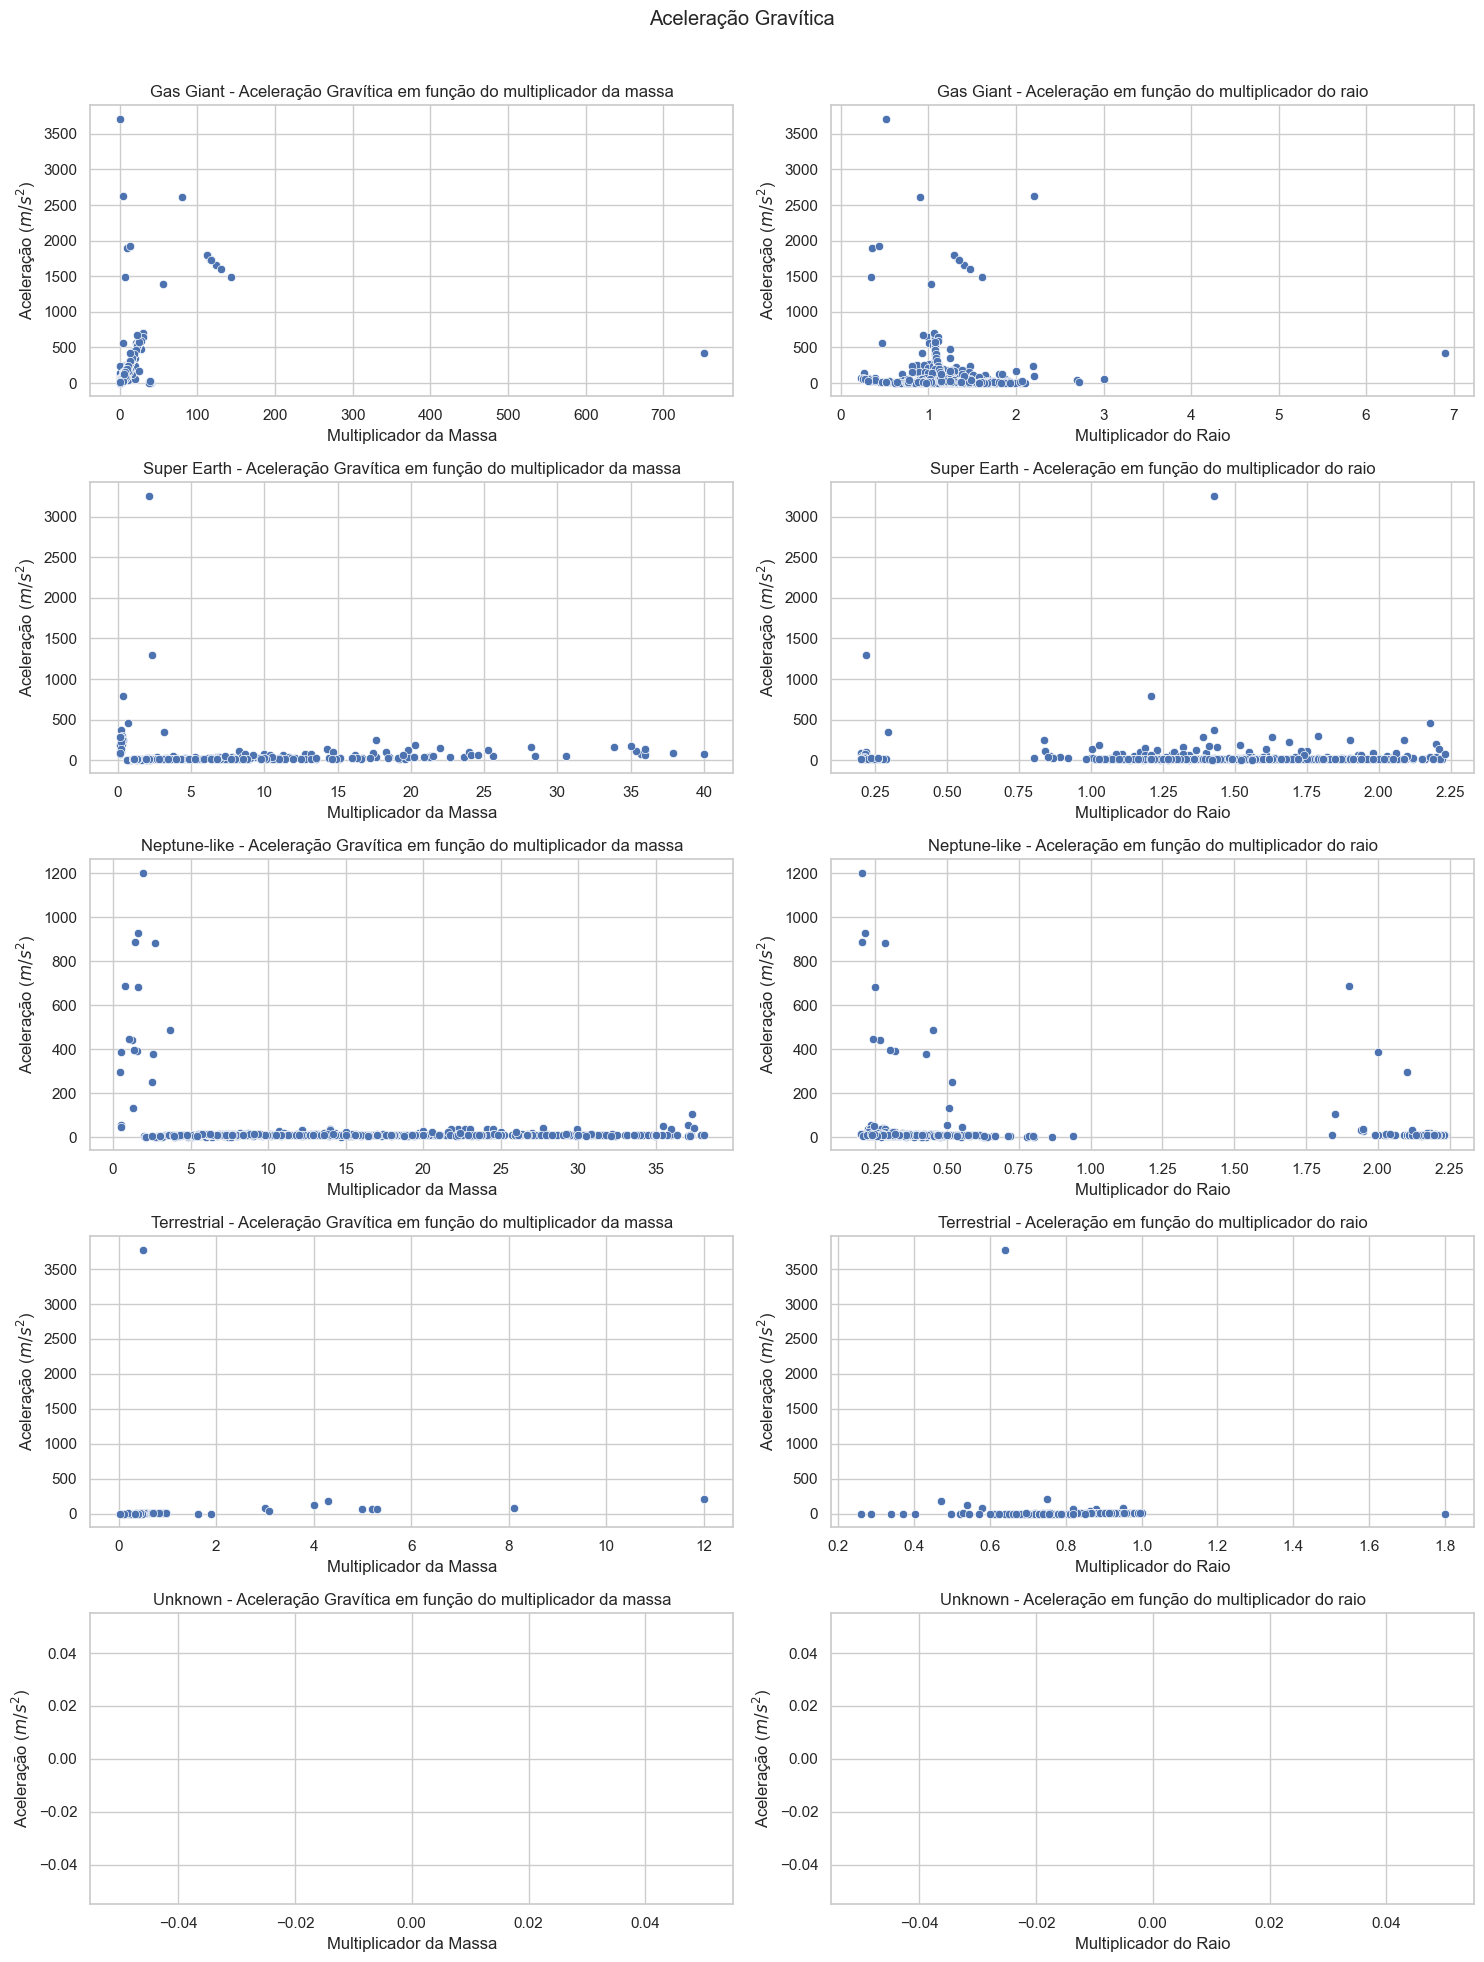

In [120]:
def acc():
    exoplanet = Exoplanet(df)
    
    exoplanet.acceleration()

    fig, axs = plt.subplots(5,2, figsize = (15, 20))
    fig.suptitle("Aceleração Gravítica")

    planet_types = df["planet_type"].unique()

    for i, planet_type in enumerate(planet_types):
        data = df[df["planet_type"] == planet_type]

        sns.scatterplot(ax = axs[i, 0], data = data, x = "mass_multiplier", y = "acceleration")
        axs[i, 0].set_title(f'{planet_type} - Aceleração Gravítica em função do multiplicador da massa')
        axs[i, 0].set_xlabel("Multiplicador da Massa")
        axs[i, 0].set_ylabel("Aceleração ($m/s^2$)")

        sns.scatterplot(ax = axs[i, 1], data = data, x ="radius_multiplier", y = "acceleration")
        axs[i, 1].set_title(f'{planet_type} - Aceleração em função do multiplicador do raio')
        axs[i, 1].set_xlabel("Multiplicador do Raio")
        axs[i, 1].set_ylabel("Aceleração ($m/s^2$)")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

acc()


Apesar de estes gráficos não terem nenhum significado físico, já que a fórmula $a=m$ ou $a=R$ não nos diz nada, estes gráficos ser-nos-ão úteis para resposta à pergunta 6. Nos últimos dois gráficos apresentam também o outro lado da ciência, onde, apesar de os planetas terem sido detetados, os instrumentos usados ainda não são precisos o suficente para saber as suas características. Fazendo uma análise na base de dados, os planetas que caem sob esta categoria de "Unknown" agrupam-se em grupos de dois ou três, com as mesmas características de distância à Terra e a magnitude estrelar, que é a unidade de medida de o quanto um objeto é brilhante, e quanto menor o número dado, menos brilhante é.

#### 4.1. Mesma pergunta, com todos os planetas

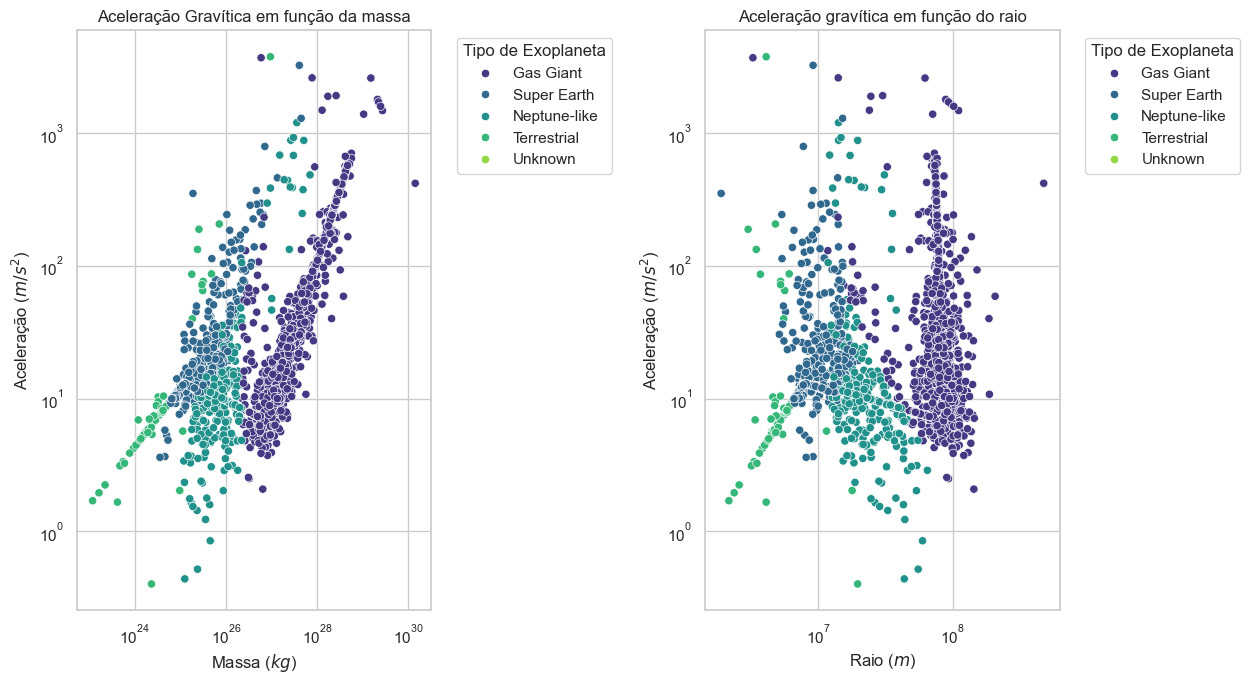

In [121]:
def acc():
    exoplanet = Exoplanet(df)
    
    exoplanet.acceleration()

    plt.figure(figsize = (15, 7))
    sns.set_theme(style = "whitegrid")

    plt.subplot(1, 2, 1)
    sns.scatterplot(data = df, x = "mass_SI", y = "acceleration", hue = "planet_type", palette = "viridis")
    plt.title("Aceleração Gravítica em função da massa")
    plt.xlabel("Massa ($kg$)")
    plt.xscale("log")
    plt.ylabel("Aceleração ($m/s^2$)")
    plt.yscale("log")
    plt.legend(title = "Tipo de Exoplaneta", bbox_to_anchor = (1.05, 1), loc = "upper left")
    
    plt.subplot(1, 2, 2)
    sns.scatterplot(data = df, x = "radius_SI", y = "acceleration", hue = "planet_type", palette = "viridis")
    plt.title("Aceleração gravítica em função do raio")
    plt.xlabel("Raio ($m$)")
    plt.xscale("log")
    plt.ylabel("Aceleração ($m/s^2$)")
    plt.yscale("log")
    plt.legend(title = "Tipo de Exoplaneta", bbox_to_anchor = (1.05, 1), loc = "upper left")

    plt.tight_layout(rect = [0, 0, 0.85, 1])
    plt.show()

acc()

### 5. Em que ano foram descobertos maior número de exoplanetas?
Usando diversos métodos de deteção ao longo dos anos, é possível determinar em que ano foram descobertos o maior número de exoplanetas, e qual foi o método de deteção mais eficaz e usado nesse ano.
Vale salientar que a deteção de exoplanetas é um processo bastante complexo, já que nem todas as estrelas têm a orbitar à sua volta exoplanetas e os planetas não emitem luz própria. Ou seja, por exemplo, os atrofísicos apontam o seu telescópio para a estrela em questão e esperam que consigam detetar alguma sombra a passar pela estrela. Essa sombra pode ser um exoplaneta.

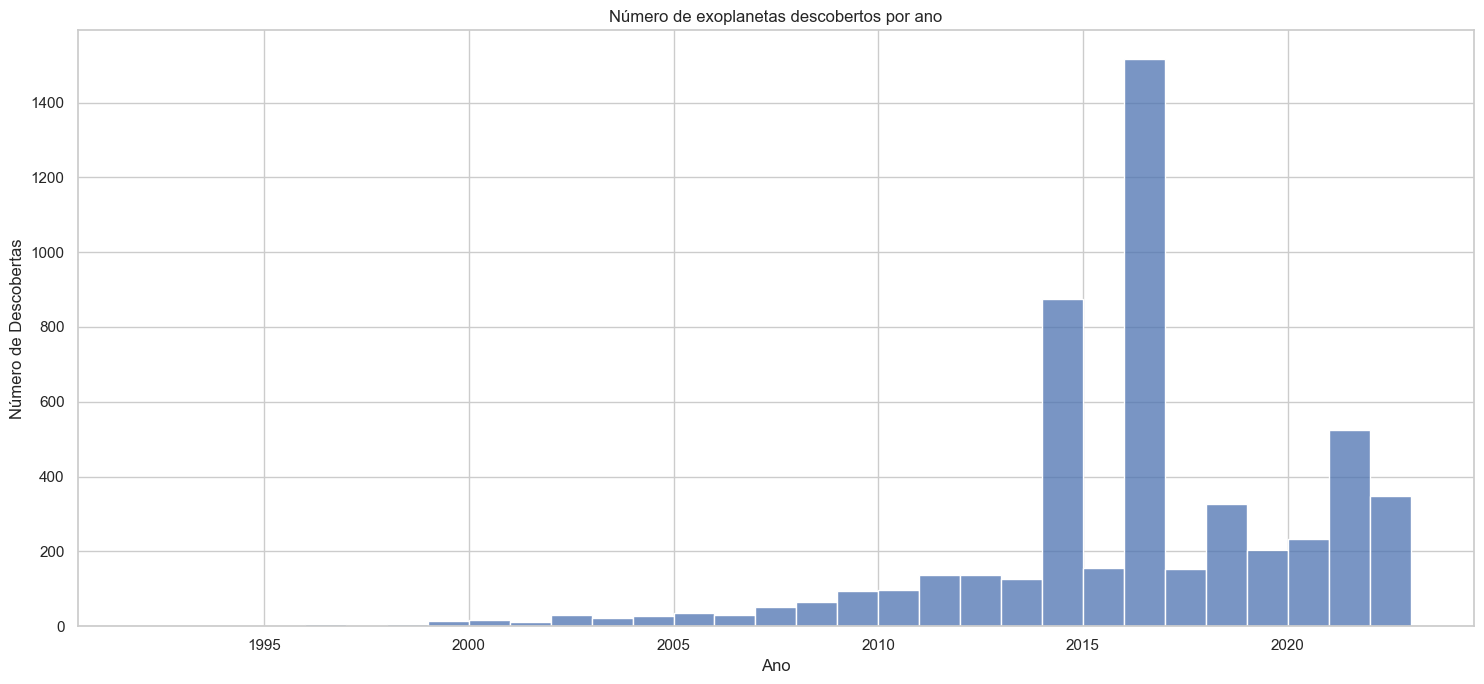

Number of discoveries in 2016: 1517


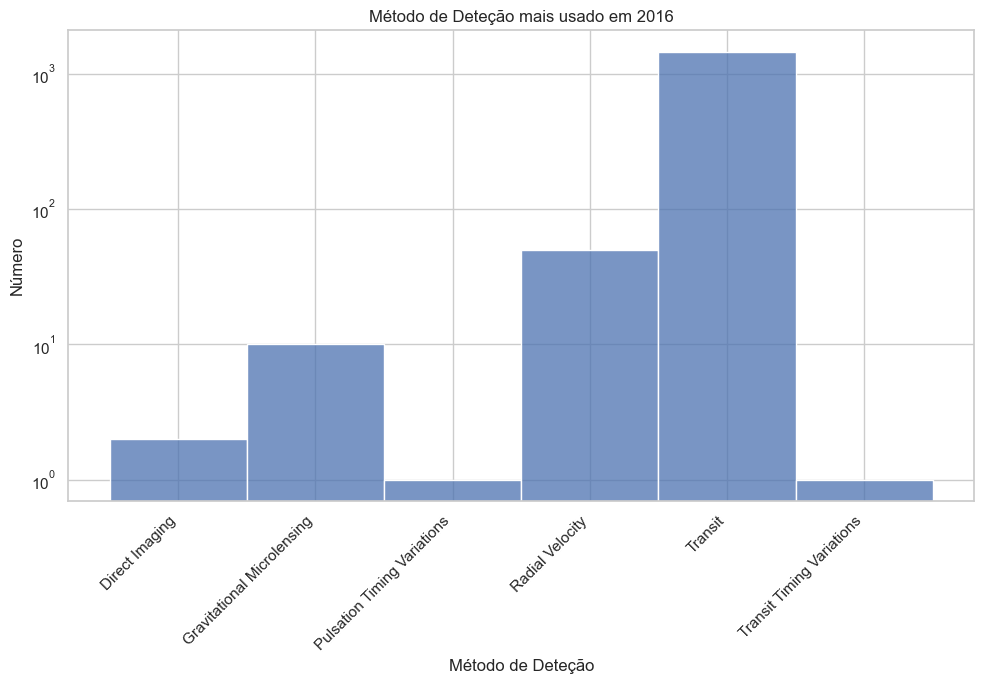

In [122]:
def year():
    exoplanet = Exoplanet(df)
    discovery_counts, max_year_method_counts = exoplanet.discovery_year()

    plt.figure(figsize = (15, 7))
    sns.set_theme(style = "whitegrid")

    sns.histplot(data = discovery_counts, x = "discovery_year", weights = "count", bins = range(int(discovery_counts["discovery_year"].min()), int(discovery_counts["discovery_year"].max()) + 1), kde=False)
    plt.title("Número de exoplanetas descobertos por ano")
    plt.xlabel("Ano")
    plt.ylabel("Número de Descobertas")
    plt.tight_layout()
    plt.show()

    discoveries_2016 = discovery_counts[discovery_counts['discovery_year'] == 2016]['count'].sum()
    print(f"Number of discoveries in 2016: {discoveries_2016}")

    # plot discovery types in year with most

    plt.figure(figsize=(10, 7))
    sns.histplot(data=max_year_method_counts, x="detection_method", weights="count", discrete=True)
    plt.title(f"Método de Deteção mais usado em {max_year_method_counts.iloc[0]['discovery_year']}")
    plt.xlabel("Método de Deteção")
    plt.ylabel("Número")
    plt.yscale("log")
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels and align them to the right
    plt.tight_layout()
    plt.show()

year()


### 6. A distância da Terra até a um dado exoplaneta é viável, num futuro onde haja criosono?
Quais são os 5 planetas mais próximos, que sejam parecidos à Terra, com uma gravidade parecida à nossa, que estejam a uma distância adequada da sua estrela. Em suma, vamos ver quais dos Super Earth's seriam os melhores candidatos para podermos, possivelmente, vivermos neles.

Os 5 exoplanetas mais próximos:
Exoplaneta: Tau Ceti e, Distância: 12.0 anos-luz, Aceleração: 11.662069297216009 m/s²
Exoplaneta: GJ 667 C g, Distância: 24.0 anos-luz, Aceleração: 11.292546717964822 m/s²
Exoplaneta: Kepler-22 b, Distância: 635.0 anos-luz, Aceleração: 66.99351463463711 m/s²
Exoplaneta: Kepler-441 b, Distância: 874.0 anos-luz, Aceleração: 12.036403948745862 m/s²
Exoplaneta: Kepler-62 f, Distância: 981.0 anos-luz, Aceleração: 171.14729368256752 m/s²


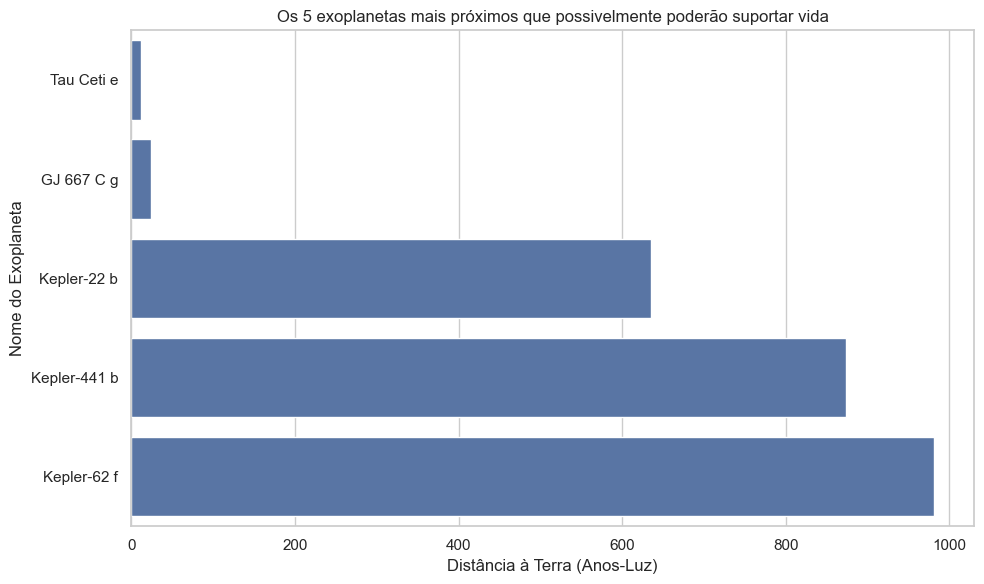

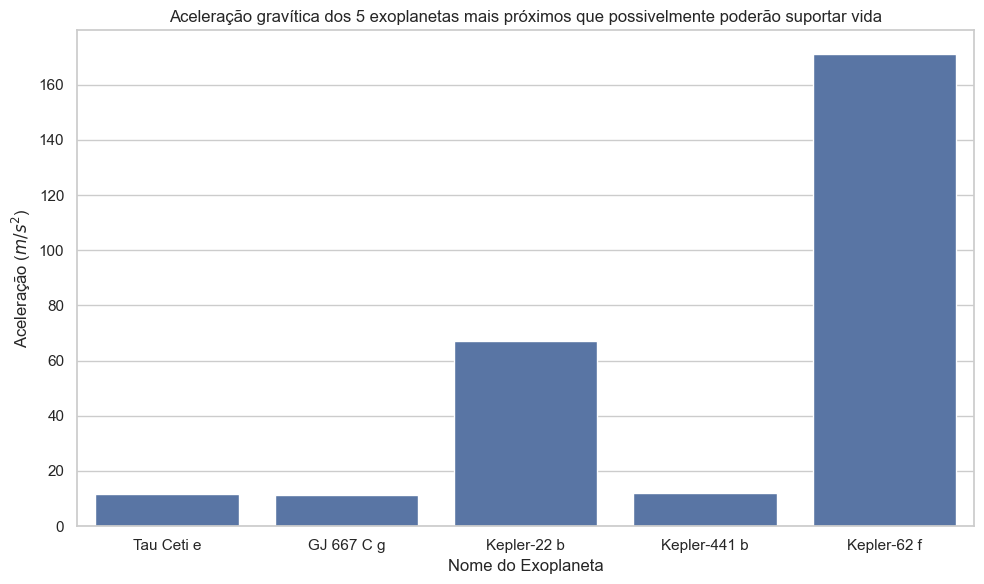

In [123]:
def viabi():
    exoplanet = Exoplanet(df)
    closest_habitable_planets = exoplanet.planet_viability()
    closest_habitable_planets = closest_habitable_planets.sort_values(by = "distance")

    ordered_list = list(zip(closest_habitable_planets["name"], closest_habitable_planets["distance"], closest_habitable_planets['acceleration']))

    print("Os 5 exoplanetas mais próximos:")
    for planet, distance, acceleration in ordered_list:
        print(f"Exoplaneta: {planet}, Distância: {distance} anos-luz, Aceleração: {acceleration} m/s²")

    plt.figure(figsize = (10, 6))
    sns.barplot(data = closest_habitable_planets, x = "distance", y = "name")
    plt.title("Os 5 exoplanetas mais próximos que possivelmente poderão suportar vida")
    plt.xlabel("Distância à Terra (Anos-Luz)")
    plt.ylabel("Nome do Exoplaneta")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize = (10, 6))
    sns.barplot(data = closest_habitable_planets, x = "name", y = "acceleration")
    plt.title("Aceleração gravítica dos 5 exoplanetas mais próximos que possivelmente poderão suportar vida")
    plt.xlabel("Nome do Exoplaneta")
    plt.ylabel("Aceleração ($m/s^2$)")
    plt.tight_layout()
    plt.show()


viabi()